In [8]:
import pandas as pd
train_model = pd.read_csv("../data/raw/train_model.csv")

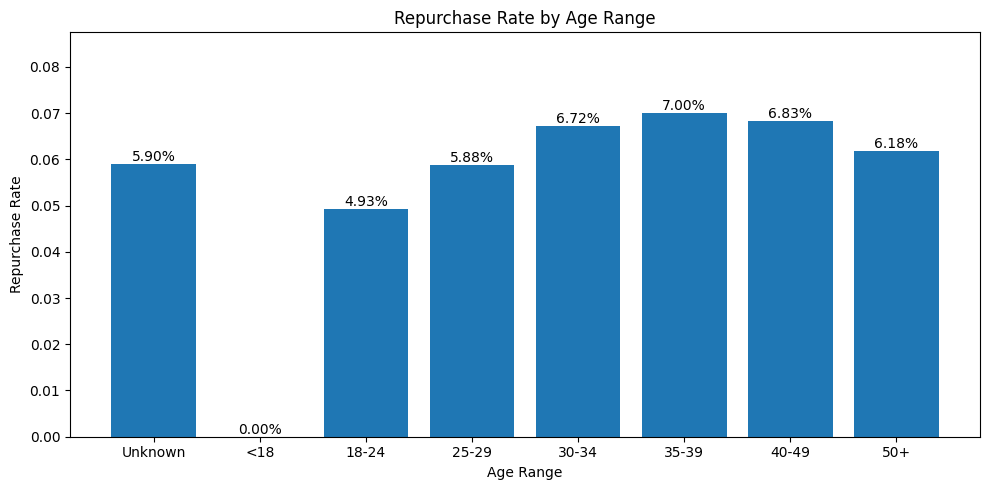

,age_label,sample_count,repurchase_count,repurchase_rate
7,Unknown,55809,3290,0.058951
6,<18,13,0,0.000000
0,18-24,31026,1531,0.049346
1,25-29,69369,4080,0.058816
2,30-34,51235,3444,0.067220
3,35-39,25618,1793,0.069990
4,40-49,21701,1483,0.068338
5,50+,4840,299,0.061777


In [9]:
import matplotlib.pyplot as plt

# 年龄段映射：根据天池官方字段说明
age_map = {
    0: "Unknown",
    1: "<18",
    2: "18-24",
    3: "25-29",
    4: "30-34",
    5: "35-39",
    6: "40-49",
    7: "50+",
    8: "50+"
}

# 统计每个年龄段的样本数、复购人数、复购率
age_summary = train_model.groupby("age_range").agg(
    sample_count=("label", "count"),
    repurchase_count=("label", "sum"),
    repurchase_rate=("label", "mean")
).reset_index()

# 映射年龄段标签
age_summary["age_label"] = age_summary["age_range"].map(age_map)

# 因为 7 和 8 都代表 50+，建议合并
age_summary = age_summary.groupby("age_label").agg(
    sample_count=("sample_count", "sum"),
    repurchase_count=("repurchase_count", "sum")
).reset_index()

age_summary["repurchase_rate"] = (
    age_summary["repurchase_count"] / age_summary["sample_count"]
)

# 自定义排序
age_order = ["Unknown", "<18", "18-24", "25-29", "30-34", "35-39", "40-49", "50+"]
age_summary["age_label"] = pd.Categorical(
    age_summary["age_label"],
    categories=age_order,
    ordered=True
)

age_summary = age_summary.sort_values("age_label")

# 画图
plt.figure(figsize=(10, 5))
bars = plt.bar(age_summary["age_label"], age_summary["repurchase_rate"])

plt.title("Repurchase Rate by Age Range")
plt.xlabel("Age Range")
plt.ylabel("Repurchase Rate")
plt.ylim(0, age_summary["repurchase_rate"].max() * 1.25)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

age_summary

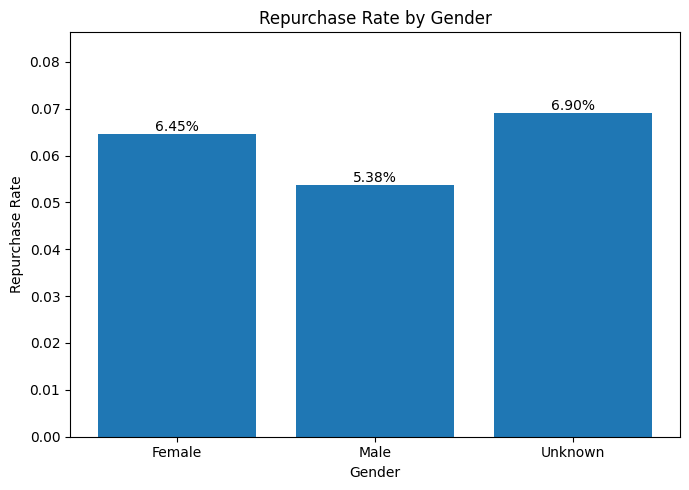

,gender_label,sample_count,repurchase_count,repurchase_rate
0,Female,176414,11387,0.064547
1,Male,73756,3969,0.053813
2,Unknown,6983,482,0.069025


In [7]:
# 性别映射：根据天池官方字段说明
gender_map = {
    0: "Female",
    1: "Male",
    2: "Unknown"
}

# 统计每个性别组的样本数、复购人数、复购率
gender_summary = train_model.groupby("gender").agg(
    sample_count=("label", "count"),
    repurchase_count=("label", "sum"),
    repurchase_rate=("label", "mean")
).reset_index()

# 映射性别标签
gender_summary["gender_label"] = gender_summary["gender"].map(gender_map)

# 如果存在空值，也归为 Unknown
gender_summary["gender_label"] = gender_summary["gender_label"].fillna("Unknown")

# 合并 Unknown
gender_summary = gender_summary.groupby("gender_label").agg(
    sample_count=("sample_count", "sum"),
    repurchase_count=("repurchase_count", "sum")
).reset_index()

gender_summary["repurchase_rate"] = (
    gender_summary["repurchase_count"] / gender_summary["sample_count"]
)

# 排序
gender_order = ["Female", "Male", "Unknown"]
gender_summary["gender_label"] = pd.Categorical(
    gender_summary["gender_label"],
    categories=gender_order,
    ordered=True
)

gender_summary = gender_summary.sort_values("gender_label")

# 画图
plt.figure(figsize=(7, 5))
bars = plt.bar(gender_summary["gender_label"], gender_summary["repurchase_rate"])

plt.title("Repurchase Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Repurchase Rate")
plt.ylim(0, gender_summary["repurchase_rate"].max() * 1.25)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

gender_summary